# Player Impact Metrics with Bootstrapped Confidence Intervals

Builds a composite player impact score from standardised per-game stats, then uses bootstrapping (1,000 resamples) to quantify uncertainty around each player's estimated impact.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
DB = '../data/database/afl_analytics.db'
conn = sqlite3.connect(DB)
np.random.seed(42)

In [2]:
# Load per-game stats for players with >= 50 career games (2012-2025, excl 2026 partial)
df = pd.read_sql("""
    SELECT p.player_name, t.team_name, s.year,
           f.disposals, f.clearances, f.contested_possessions,
           f.inside_50s, f.tackles, f.goals, f.marks_inside_50
    FROM fact_player_match_stats f
    JOIN dim_players p ON f.player_key  = p.player_key
    JOIN dim_teams   t ON f.team_key    = t.team_key
    JOIN dim_seasons s ON f.season_key  = s.season_key
    WHERE s.year <= 2025
      AND f.disposals IS NOT NULL
""", conn)

# Keep only players with >= 50 career games
game_counts = df.groupby('player_name').size()
eligible = game_counts[game_counts >= 50].index
df = df[df.player_name.isin(eligible)].copy()
print(f'Games: {len(df):,}  |  Eligible players: {df.player_name.nunique()}')

Games: 112,285  |  Eligible players: 868


In [3]:
# Composite impact score: z-score each stat league-wide, then average
stat_cols = ['disposals','clearances','contested_possessions','inside_50s','tackles','goals','marks_inside_50']
# Goals and marks_inside_50 are positional (forwards outscore mids/backs) — weight them lower
weights = {'disposals':1.0,'clearances':1.2,'contested_possessions':1.0,
           'inside_50s':1.0,'tackles':1.0,'goals':0.5,'marks_inside_50':0.5}

for col in stat_cols:
    df[f'z_{col}'] = (df[col] - df[col].mean()) / df[col].std()

df['impact_score'] = sum(df[f'z_{c}'] * w for c, w in weights.items()) / sum(weights.values())

print('Impact score distribution:')
print(df['impact_score'].describe().round(3))

Impact score distribution:
count    112285.000
mean          0.000
std           0.652
min          -1.277
25%          -0.471
50%          -0.123
75%           0.355
max           3.934
Name: impact_score, dtype: float64


In [4]:
# Bootstrap CI for each player's mean impact score
N_BOOT = 1000

def bootstrap_ci(series, n_boot=N_BOOT, ci=95):
    boots = [series.sample(len(series), replace=True).mean() for _ in range(n_boot)]
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return series.mean(), lo, hi

results = []
for player, grp in df.groupby('player_name'):
    mean_imp, lo, hi = bootstrap_ci(grp['impact_score'])
    results.append({
        'player_name': player,
        'team_name':   grp['team_name'].mode()[0],
        'games':       len(grp),
        'mean_impact': mean_imp,
        'ci_lo':       lo,
        'ci_hi':       hi,
        'ci_width':    hi - lo
    })

impact_df = pd.DataFrame(results).sort_values('mean_impact', ascending=False)
print('Top 10 players by impact score:')
print(impact_df.head(10)[['player_name','team_name','games','mean_impact','ci_lo','ci_hi']].to_string(index=False))

Top 10 players by impact score:
         player_name         team_name  games  mean_impact    ci_lo    ci_hi
     Oliver, Clayton         Melbourne    205     1.309087 1.220023 1.398508
       Priddis, Matt West Coast Eagles    132     1.302848 1.202922 1.397901
     Cripps, Patrick           Carlton    230     1.258670 1.169768 1.348739
Dangerfield, Patrick           Geelong    296     1.211877 1.128948 1.294837
        Ablett, Gary   Gold Coast Suns    145     1.194322 1.058847 1.328914
        Rowell, Matt   Gold Coast Suns    110     1.189558 1.037703 1.325903
 Bontempelli, Marcus  Western Bulldogs    258     1.131319 1.053033 1.217457
       Serong, Caleb         Fremantle    127     1.083232 0.958694 1.197544
        Beams, Dayne       Collingwood    118     1.068684 0.947089 1.189429
          Swan, Dane       Collingwood     83     1.058947 0.913325 1.204903


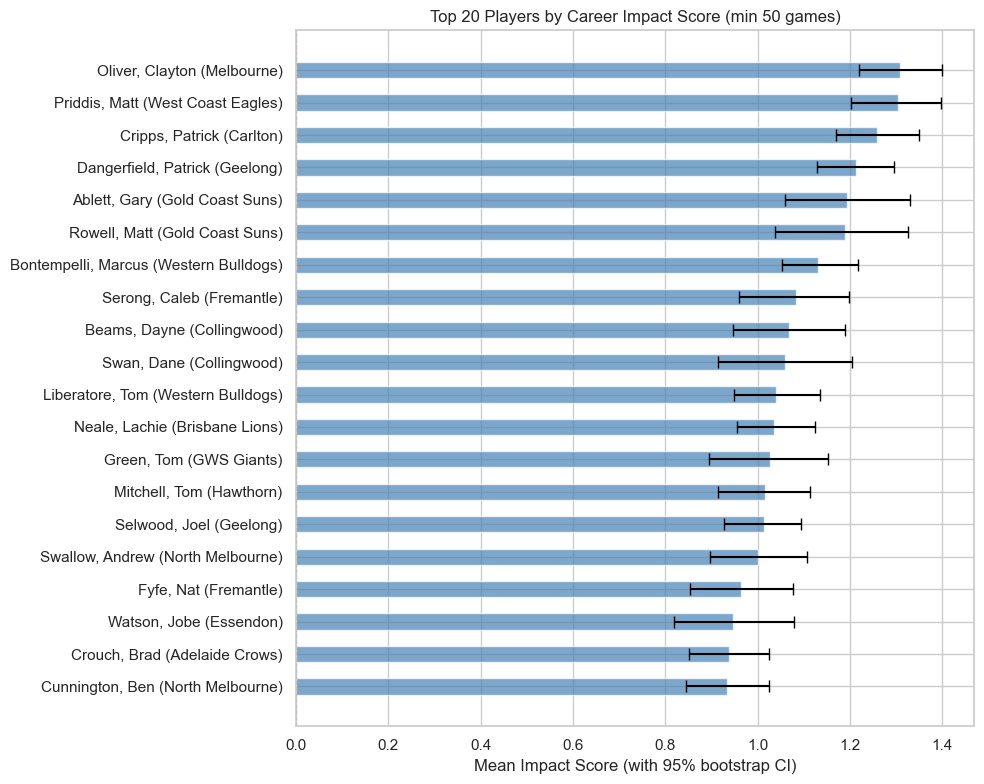

In [5]:
# Plot top 20 with confidence intervals
top20 = impact_df.head(20).sort_values('mean_impact')

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(top20))
ax.barh(y_pos, top20['mean_impact'], color='steelblue', alpha=0.7, height=0.5)
ax.errorbar(
    top20['mean_impact'], y_pos,
    xerr=[top20['mean_impact'] - top20['ci_lo'], top20['ci_hi'] - top20['mean_impact']],
    fmt='none', color='black', capsize=4, linewidth=1.5
)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r.player_name} ({r.team_name})" for r in top20.itertuples()])
ax.set_xlabel('Mean Impact Score (with 95% bootstrap CI)')
ax.set_title('Top 20 Players by Career Impact Score (min 50 games)')
ax.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.tight_layout()
plt.show()

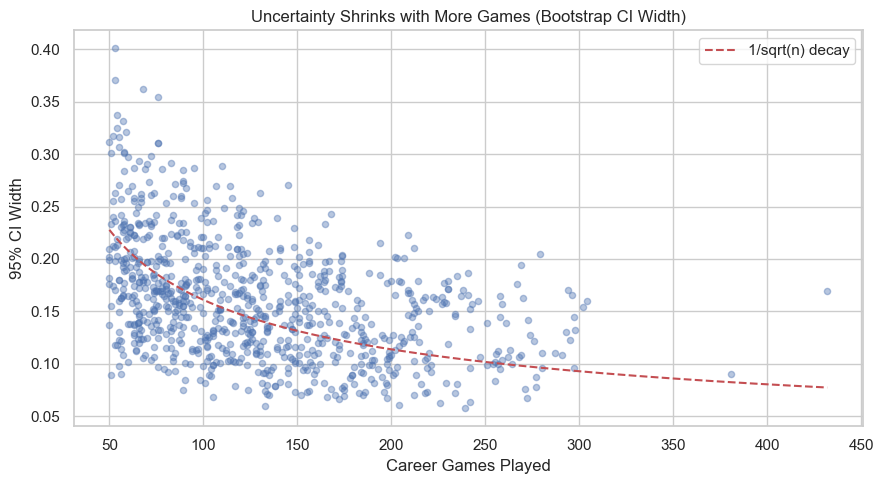

In [6]:
# CI width vs games played — more games = tighter CI
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(impact_df['games'], impact_df['ci_width'], alpha=0.4, s=20)
ax.set_xlabel('Career Games Played')
ax.set_ylabel('95% CI Width')
ax.set_title('Uncertainty Shrinks with More Games (Bootstrap CI Width)')
# Overlay a decay curve
x = np.linspace(impact_df['games'].min(), impact_df['games'].max(), 200)
# Expected: CI width ~ 1/sqrt(n) * constant
k = impact_df[['games','ci_width']].eval('ci_width * games**0.5').median()
ax.plot(x, k / np.sqrt(x), 'r--', lw=1.5, label='1/sqrt(n) decay')
ax.legend()
plt.tight_layout()
plt.show()

conn.close()